**An embedding vector** is a long list of numbers (384 of them, for the model we're using) that represents the *meaning* of a piece of text — not its words, its meaning.
- Two sentences that say the same thing in completely different words end up as two vectors that point in **almost the same direction** in that 384-dimensional space
- Two sentences about unrelated topics end up pointing in **very different directions**, even if they happen to share some of the same words
- This is the entire trick behind semantic search, clustering, and retrieval — "similar meaning" becomes "nearby points," which is something math can actually operate on
- **One thing to know up front**: Anthropic does **not** make an embedding model — Claude generates language, it doesn't produce fixed-size meaning-vectors, those are different jobs done by different kinds of models. This chapter uses a free, open-source model running **locally on your own machine** instead — no separate API account, no separate key, no per-call cost

**Generating embeddings for a batch of emails** should always mean one call carrying many texts, not many calls carrying one text each — true whether that call goes over a network or runs locally.
- `model.encode(texts, normalize_embeddings=True)` takes a **list** of strings and returns a **list** of vectors — embedding 45 emails is one function call, not 45
- `normalize_embeddings=True` scales every output vector to length 1 — this is exactly what makes the cosine-similarity shortcut in the next note work
- The model, `paraphrase-multilingual-MiniLM-L12-v2`, downloads once from Hugging Face (a few hundred MB, cached after that) and then runs entirely on your own CPU/GPU — no internet needed after the first run, no rate limits, no bill
- The result is a NumPy array of shape `(number_of_emails, 384)` — one row per email, ready to feed straight into similarity math or dimensionality reduction

**Cosine similarity** measures how close two vectors' *directions* are, ignoring how long either vector happens to be — which is exactly the right notion of "closeness" for meaning.
- The formula is `dot(a, b) / (‖a‖ × ‖b‖)` — the dot product, scaled down by both vectors' magnitudes, so the result always lands between **-1** (opposite meaning) and **1** (identical meaning)
- **Useful shortcut**: since `embed_texts()` calls `encode()` with `normalize_embeddings=True`, every vector's magnitude is already exactly 1 — meaning the plain dot product **alone** already equals the cosine similarity, no division needed. The script computes it the long way once, then proves the shortcut holds with a direct check
- The real test in the script: two FD emails about the *same* underlying complaint (money not credited) but written in completely different words, compared against an unrelated Non-FD email — the FD-to-FD similarity should clearly beat the FD-to-Non-FD similarity, despite zero word overlap forcing that result

**Visualizing embedding clusters** means taking a stack of 384-dimensional vectors and forcing them down to 2 dimensions you can actually look at on a screen.
- A stratified sample (15 per class, 45 emails total) gets embedded in **one** batch call — same discipline as Chapter 5's dev set, for the same reason: a fair, equal-sized look at every class
- **PCA** (Principal Component Analysis) finds the 2 directions in that 384-dimensional space that capture the most spread in the data, and projects every point onto just those 2 — it's a compression, not a redraw, so some information is genuinely lost
- The `explained_variance_ratio_` the script prints tells you **how much** was lost — if 2 components only capture 30% of the spread, the 2D picture is a rough sketch, not the full story; that number is worth reading, not skipping past
- What a "good" plot looks like here: the 3 colors (FD / Non-FD / Multiple Category) forming roughly separate regions, even loosely — that's visual confirmation the embedding space is picking up the same distinction your labels already encode

**Connecting this to MuRIL's `[CLS]` vector** — you've already built this exact concept once before, just inside a different model, and the parallel is even closer now than it was with Voyage.
- MuRIL is a BERT-style model — its `[CLS]` token's final hidden state **is** an embedding: a fixed-size vector meant to summarize the whole input, used for downstream classification
- The difference here isn't conceptual, it's **architectural separation**: MuRIL produced an embedding *and* a classification decision from one fine-tuned model in one pass; here, embeddings come from one small specialized model and classification comes from a completely different, much larger one (Claude) — two purpose-built tools instead of one model wearing two hats
- Now that both steps run **locally, with no API call at all** — MuRIL on your own GPU, this embedding model on your own CPU — the only real difference left between them is *scale* and *purpose*, not "local model vs. API call," which was a distinction that only existed because of the now-removed Voyage dependency
- Both vectors live in a real geometric space where distance means semantic distance — that's not a coincidence, it's the entire reason `[CLS]` vectors and these embedding vectors are comparable concepts in the first place, despite coming from architecturally unrelated models

In [1]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
EMBED_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"  # 384-dim, multilingual
DATA_PATH = "fd_dataset_messy.csv"
 
model = SentenceTransformer(EMBED_MODEL_NAME)
print(model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
)


In [3]:
def embed_texts(texts: list) -> np.ndarray:
    """Sub-topic 2: one call embeds the whole batch at once, on your own
    CPU/GPU -- no network round trip, no per-call cost. normalize_embeddings
    =True keeps the same nice property used below: cosine similarity
    becomes just a dot product. Returns an array of shape (len(texts), 384)."""
    return model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
 

In [4]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Sub-topic 3: the general formula -- dot product over the product of
    magnitudes. Since embed_texts() above set normalize_embeddings=True,
    every vector already has magnitude 1, so np.dot(a, b) alone gives the
    identical answer at lower cost. Written out in full here for the
    concept; the "sanity check" print below confirms the shortcut holds."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
 

Cosine similarity -- same meaning in different words vs. different topic
FD complaint A : The machurity proceeds of my FD BJ2024FD4422 were supposed to come to ...
FD complaint B : Hello ji, My amnt is pending from your side since June. Plz credit it ...
Non-FD email   : Sir ji, App me login nahi ho raha. OTP aata hi nahi. Teen din se try k...

similarity(FD-A, FD-B)   = 0.4528   <- different words, same complaint
similarity(FD-A, Non-FD) = 0.4135   <- different topic entirely

(sanity check) dot product == cosine similarity for normalized vectors: True

Visualizing embedding clusters across all 3 classes
Embedding 45 emails in one batch call...
Embeddings shape: (45, 384)
PCA explained variance (2 components): 22.8%
Saved plot to embedding_clusters.png


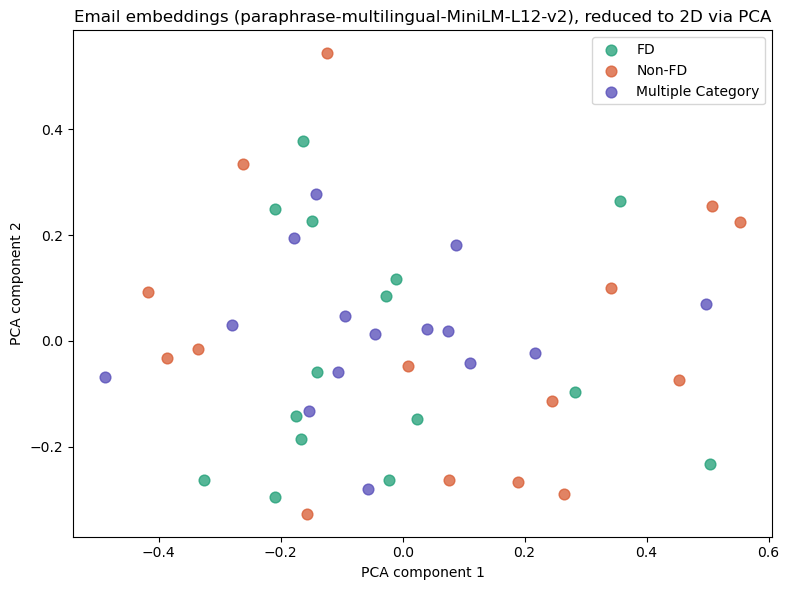

In [5]:
if __name__ == "__main__":
    # ------------------------------------------------------------------
    # Sub-topic 3: cosine similarity on 3 REAL emails -- two FD complaints
    # worded completely differently, one unrelated Non-FD email.
    # ------------------------------------------------------------------
    email_fd_a = (
        "The machurity proceeds of my FD BJ2024FD4422 were supposed to come "
        "to my bank account but nothing recieved yet. Where is my money? "
        "Thanks, Geeta Pandey"
    )
    email_fd_b = (
        "Hello ji, My amnt is pending from your side since June. Plz credit "
        "it fast to my bank. Thanks and regards, Meena Patel"
    )
    email_non_fd = (
        "Sir ji, App me login nahi ho raha. OTP aata hi nahi. Teen din se "
        "try kar raha hoon. Kya problem hai?"
    )
 
    print("=" * 70)
    print("Cosine similarity -- same meaning in different words vs. different topic")
    print("=" * 70)
 
    vecs = embed_texts([email_fd_a, email_fd_b, email_non_fd])
    vec_fd_a, vec_fd_b, vec_non_fd = vecs[0], vecs[1], vecs[2]
 
    sim_fd_fd = cosine_similarity(vec_fd_a, vec_fd_b)
    sim_fd_nonfd = cosine_similarity(vec_fd_a, vec_non_fd)
 
    print(f"FD complaint A : {email_fd_a[:70]}...")
    print(f"FD complaint B : {email_fd_b[:70]}...")
    print(f"Non-FD email   : {email_non_fd[:70]}...")
    print()
    print(f"similarity(FD-A, FD-B)   = {sim_fd_fd:.4f}   <- different words, same complaint")
    print(f"similarity(FD-A, Non-FD) = {sim_fd_nonfd:.4f}   <- different topic entirely")
    print(f"\n(sanity check) dot product == cosine similarity for normalized vectors: "
          f"{np.isclose(np.dot(vec_fd_a, vec_fd_b), sim_fd_fd)}")
 
    # ------------------------------------------------------------------
    # Sub-topic 4: embedding clusters across FD / Non-FD / Multiple Category
    # ------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("Visualizing embedding clusters across all 3 classes")
    print("=" * 70)
 
    df = pd.read_csv('../data/fd_dataset_messy.csv')
    N_PER_CLASS = 15
    sample = (
        df.groupby("label", group_keys=False)
        .sample(n=N_PER_CLASS, random_state=42)
        .reset_index(drop=True)
    )
    texts = [f"Subject: {r.subject}\n\nBody: {r.content}" for r in sample.itertuples()]
 
    print(f"Embedding {len(texts)} emails in one batch call...")
    embeddings = embed_texts(texts)
    print(f"Embeddings shape: {embeddings.shape}")
 
    pca = PCA(n_components=2, random_state=42)
    points_2d = pca.fit_transform(embeddings)
    print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")
 
    colors = {"FD": "#1D9E75", "Non-FD": "#D85A30", "Multiple Category": "#534AB7"}
    plt.figure(figsize=(8, 6))
    for label, color in colors.items():
        mask = (sample["label"] == label).to_numpy()
        plt.scatter(points_2d[mask, 0], points_2d[mask, 1],
                    label=label, color=color, alpha=0.75, s=60)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(f"Email embeddings ({EMBED_MODEL_NAME}), reduced to 2D via PCA")
    plt.legend()
    plt.tight_layout()
    plt.savefig("embedding_clusters.png", dpi=150)
    print("Saved plot to embedding_clusters.png")